In [1]:
import os
import json
from pathlib import Path

import torch
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)
from qwen_vl_utils import process_vision_info

MODEL_DIR = Path(r"../Qwen2.5-VL-3B-Instruct") # указываем путь до используемой модели
IMAGE_DIR = "./data"
OUTPUT_FILE = "./dataset.jsonl"

if not MODEL_DIR.is_dir():
    raise FileNotFoundError(f"Каталог модели не найден: {MODEL_DIR}")

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    str(MODEL_DIR),
    device_map="auto",
    torch_dtype=torch.float16,
    quantization_config=quantization_config,
    local_files_only=True,
)

processor = AutoProcessor.from_pretrained(
    str(MODEL_DIR),
    local_files_only=True,
)

print("Модель загружена из:", MODEL_DIR.resolve())


/home/shion/PycharmProjects/designing_neural_network_architectures_2025_02/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[ERROR] `loss` is part of Qwen2_5_VLCausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in /home/shion/PycharmProjects/designing_neural_network_architectures_2025_02/.venv/lib/python3.13/site-packages/transformers/models/qwen2_5_vl/modeling_qwen2_5_vl.py.
[ERROR] `logits` is part of Qwen2_5_VLCausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in /home/shion/PycharmProjects/designing_neural_network_architectures_2025_02/.venv/lib/python3.13/site-packages/transformers/models/qwen2_5_vl/modeling_qwen2_5_vl.py.


Loading weights: 100%|██████████| 824/824 [00:02<00:00, 369.31it/s]


Модель загружена из: /home/shion/PycharmProjects/designing_neural_network_architectures_2025_02/Qwen2.5-VL-3B-Instruct


In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
CUDA version: 12.4
GPU count: 1
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


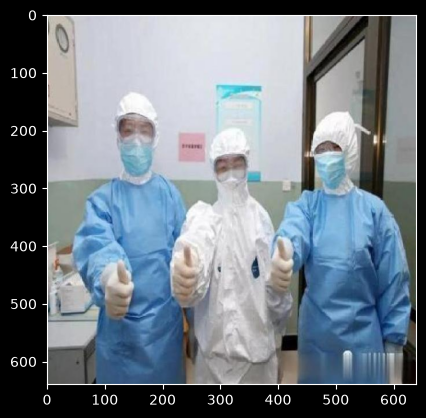

Промпт: Сколько людей в кадре? Опиши их очень подробно
Ответ: В кадре изображены три человека, одетых в медицинскую одежду.

1. Левый человек:
   - Одет в синюю медицинскую одежду.
   - Носит защитный шлем.
   - Носит медицинскую маску.
   - Носит перчатки.
   - Позирует, держа руку вверху.

2. (равныйв левойную сторону:

Правый человек:
- Одет в синюю медицинскую одежду.
- Носит защитный шлем.
- Носит медицинскую маску.
- Носит перчатки.
- Позирует, держа руку вверху.

3. Средний человек:
   - Одет в белую медицинскую одежду.
   - Носит защитный шлем.
   - Носит медицинскую маску.
   - Носит перчатки.
   - Позирует, держа руку вверху.

 Все три человекачика позируют, держа руку вверху.


In [4]:
import matplotlib.pyplot as plt
import cv2

TEST_IMAGE = Path("./data/0000000013_jpg.rf.a7b4df633397510725f11d8daa0592cb.jpg")  # путь к картинке

image = cv2.imread(TEST_IMAGE)[:,:,::-1]
plt.imshow(image)
plt.show()

TEST_PROMPT = "Сколько людей в кадре? Опиши их очень подробно"

if not TEST_IMAGE.is_file():
    raise FileNotFoundError(f"Картинка не найдена: {TEST_IMAGE.resolve()}")

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": str(TEST_IMAGE)},
            {"type": "text", "text": TEST_PROMPT},
        ],
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to(model.device)

generated_ids = model.generate(
    **inputs,
    max_new_tokens=256,
    do_sample=False,
)

generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

answer = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0]

print("Промпт:", TEST_PROMPT)
print("Ответ:", answer)


In [7]:

PROMPT = """
Опиши изображение кратко и информативно.
Укажи:
- главные объекты
- действия
- сцену
Ответь одним предложением.
ОПИСЫВАЙ МАКСИМАЛЬНО ПОДРОБНО, КАЖДЫЙ ЭЛЕМЕНТ, КАЖДОЕ ДЕЙСТВИЕ!!!
"""

all_items = []

files = sorted(os.listdir(IMAGE_DIR))

for file_name in files:

    if not file_name.lower().endswith(
        (".jpg", ".jpeg", ".png", ".webp")
    ):
        continue

    image_path = os.path.join(IMAGE_DIR, file_name)

    print(f"Processing: {file_name}")

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image_path
                },
                {
                    "type": "text",
                    "text": PROMPT
                }
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )

    inputs = inputs.to(model.device)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=512,
        do_sample=False
    )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(
            inputs.input_ids,
            generated_ids
        )
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    item = {
        "image": image_path,
        "text": output_text
    }

    all_items.append(item)

    print(output_text)


Processing: -01-16-2-3-2-5-15_jpg.rf.3a82c0e7cb6b006df4c9fc87d9b55368.jpg
Главные объекты: человек в черной футболке и светло-серые брюки, стеллаж с коричневыми коробками, стол, тумбочка, холодильник, кухонная мебель, настенные вытяжки, витрина, настенные полки, настенные вытяжки, настенные полки, настенные вытяжки, настенные полки, настенные вытяжки, настенные полки, настенные вытяжки, настенные полки, настенные вытяжки, настенные полки, настенные вытяжки, настенные полки, настенные вытяжки, настенные полки, настенные вытяжки, настенные полки, настенные вытяжки, настенных полки, настенных вытяжках, настенных полки, настенных вытяжках, настенных полки, настенных вытяжках, настенных полки, настенных вытяжках, настенных полки, настенных вытяжках, настенных полки, настенных вытяжках, настенных полки, настенных вытяжках, настенных полки, настенных вытяжках, настенных полки, настенных вытяжках, настенных полки, настенных вытяжках, настенных полки, настенных вытяжках, настенных полки, настен

In [8]:


with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    for item in all_items:
        f.write(
            json.dumps(item, ensure_ascii=False) + "\n"
        )

print(f"Saved to {OUTPUT_FILE}")


Saved to ./dataset.jsonl
